# Week 2 solution — Describing data properly

In [1]:
import math9102 as m9
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

m9.use_house_style()

experim = m9.load_experim()

---

## Question 1 — Orient yourself

In [2]:
print(experim.shape)
experim.dtypes

(30, 18)


id            int64
sex             str
age           int64
group           str
fost1         int64
confid1       int64
depress1      int64
fost2         int64
confid2       int64
depress2      int64
fost3         int64
confid3       int64
depress3      int64
exam          int64
mah_1       float64
dept1gp2        str
dept2gp2        str
dept3gp2        str
dtype: object

In [3]:
experim.head()

,id,sex,age,group,fost1,confid1,depress1,fost2,confid2,depress2,fost3,confid3,depress3,exam,mah_1,dept1gp2,dept2gp2,dept3gp2
0,4,male,23,confidence building,50,15,44,48,16,44,45,14,40,52,0.569984,not depressed,not depressed,not depressed
1,10,male,21,confidence building,47,14,42,45,15,42,44,18,40,55,1.659403,not depressed,not depressed,not depressed
2,9,male,25,maths skills,44,12,40,39,18,40,36,19,38,58,3.540472,not depressed,not depressed,not depressed
3,3,male,30,maths skills,47,11,43,42,16,43,41,20,43,60,2.454214,not depressed,not depressed,not depressed
4,12,male,45,confidence building,46,16,44,45,16,45,43,20,43,58,0.944304,not depressed,depressed,not depressed


In [4]:
print(f"students: {len(experim)}")
print(f"missing values anywhere in the dataset: {experim.isna().sum().sum()}")

students: 30
missing values anywhere in the dataset: 0


**A row is one student**, measured on the same scales three times.

That matters more than it looks. `fost1`, `fost2` and `fost3` are **not three
independent variables**. They are one variable measured on the same people at
three points, so any comparison between them is a *paired* comparison. Treating
them as independent groups would discard the pairing, which is where most of the
precision in a before-and-after design lives.

This is a fictitious, manufactured dataset with no missing values anywhere,
which is itself a warning: real data does not look like this.

---

## Question 2 — Describe the sample

In [5]:
m9.frequency(experim, "group")

,count,percent,valid_percent
group,,,
confidence building,15,50.0,50.0
maths skills,15,50.0,50.0


In [6]:
m9.frequency(experim, "sex")

,count,percent,valid_percent
sex,,,
female,15,50.0,50.0
male,15,50.0,50.0


In [7]:
m9.crosstab(experim, "group", "sex")

sex,female,male
group,,
confidence building,8,7
maths skills,7,8


In [8]:
m9.describe_by(experim, "age", "group")

,n,missing,mean,sd,se,median,iqr,min,max,skew,kurtosis
group,,,,,,,,,,,
confidence building,15.0,0.0,26.267,8.345,2.155,23.0,6.5,19.0,45.0,1.731,1.992
maths skills,15.0,0.0,25.533,7.347,1.897,23.0,5.0,19.0,46.0,1.912,3.723


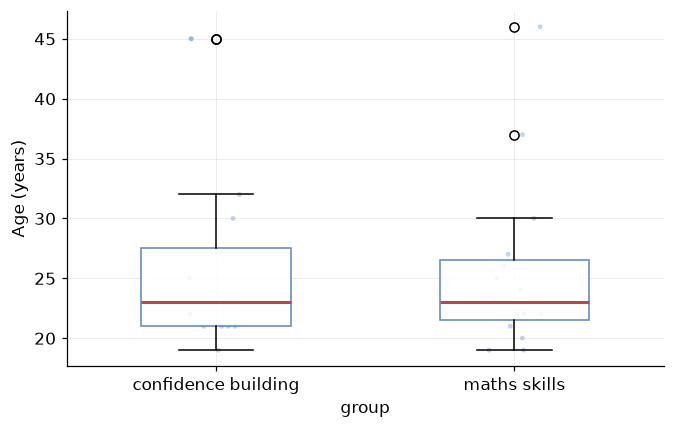

In [9]:
m9.grouped_box(experim, "age", "group", ylabel="Age (years)");

**Balance.** The two groups are exactly equal in size, and sex is split as
evenly as fifteen allows. Age is close on the medians but the distributions are
right-skewed in both groups, so compare the medians rather than the means.

**What these data cannot tell you.** Whether students were *randomly assigned*
to the two groups. Balance on the variables you happen to have recorded is weak
evidence for it and no evidence at all about the variables you did not record —
prior statistics experience, for example, which would plausibly affect both fear
and exam performance. Randomisation is a fact about the procedure, and it has to
be reported, not inferred.

---

## Question 3 — Centre, spread and shape

In [10]:
m9.describe(experim, ["fost1", "exam"])

,n,missing,mean,sd,se,median,iqr,min,max,skew,kurtosis
fost1,30,0,40.167,5.160,0.942,40.0,6.75,30.0,50.0,-0.190,-0.575
exam,30,0,68.333,10.854,1.982,65.5,19.50,52.0,90.0,0.344,-1.103


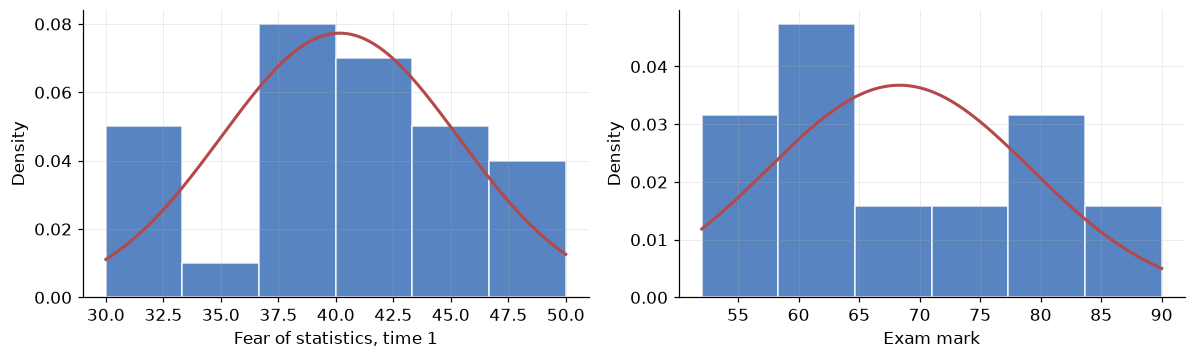

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
m9.histogram_with_normal(experim.fost1, xlabel="Fear of statistics, time 1", ax=axes[0])
m9.histogram_with_normal(experim.exam, xlabel="Exam mark", ax=axes[1])
fig.tight_layout();

In [12]:
for col in ("fost1", "exam"):
    x = experim[col]
    print(f"{col:6s} mean {x.mean():6.2f}  median {x.median():6.2f}  "
          f"skew {stats.skew(x):+.2f}  kurtosis {stats.kurtosis(x):+.2f}")

fost1  mean  40.17  median  40.00  skew -0.18  kurtosis -0.68
exam   mean  68.33  median  65.50  skew +0.33  kurtosis -1.12


**`fost1`.** Mean and median are close, skew is near zero, and the histogram is
roughly symmetric. Report the **mean and standard deviation**.

**`exam`.** The mean sits above the median and the skew is positive, but the
more striking feature is the negative kurtosis: the distribution is flat and
broad rather than peaked, closer to spread-out than to bell-shaped. Neither
summary is wrong here, but the **median and IQR** describe it more honestly, and
either way the shape has to be reported alongside.

**A caution about both.** With thirty observations, skew and kurtosis are
estimated very imprecisely. They are worth reporting as descriptions and are not
worth arguing over — the histogram is doing more work than the numbers.

---

## Question 4 — Standardise

In [13]:
z_exam = (experim.exam - experim.exam.mean()) / experim.exam.std(ddof=1)
z_fost = (experim.fost1 - experim.fost1.mean()) / experim.fost1.std(ddof=1)

print(f"mean of z_exam = {z_exam.mean():.6f}, SD = {z_exam.std(ddof=1):.6f}")

mean of z_exam = 0.000000, SD = 1.000000


In [14]:
student = experim.index[experim.id == 4][0]

print(f"raw:  exam = {experim.exam[student]}, fost1 = {experim.fost1[student]}")
print(f"z:    exam = {z_exam[student]:+.2f}, fost1 = {z_fost[student]:+.2f}")

raw:  exam = 52, fost1 = 50
z:    exam = -1.50, fost1 = +1.91


**By z-score, on fear of statistics.** The fear score sits further from its
mean, in standard-deviation terms, than the exam mark sits from its own.

**Why the raw numbers cannot answer it.** An exam mark and a fear-of-statistics
score are measured on different scales with different spreads, so "52 versus 50"
compares nothing. Standardising expresses both as *distance from the mean of
their own distribution*, in units of that distribution's own spread, which is a
comparison that means something.

In [15]:
print(f"share of the group scoring lower on the exam: "
      f"{(experim.exam < experim.exam[student]).mean():.1%}")
print(f"share of the group scoring lower on fear: "
      f"{(experim.fost1 < experim.fost1[student]).mean():.1%}")

share of the group scoring lower on the exam: 0.0%
share of the group scoring lower on fear: 96.7%


**Ranks cannot separate the two.** Nobody scored lower on the exam and nobody
was more afraid: this student holds the lowest exam mark and the highest fear
score of all thirty. The z-scores do separate them, and part of the reason is
shape. The exam results are spread flat and broad — Question 3 found clearly
negative kurtosis — so even the lowest mark is not many standard deviations
from the mean. A distance in standard deviations translates into rarity only
when the distribution is close to normal. So answer with the z-scores, as asked,
and say that the gap between them owes something to the shape of the exam
distribution.

---

## Question 5 — Choose the right picture, four times

### 5.1 Fear of statistics, time 1 against time 2

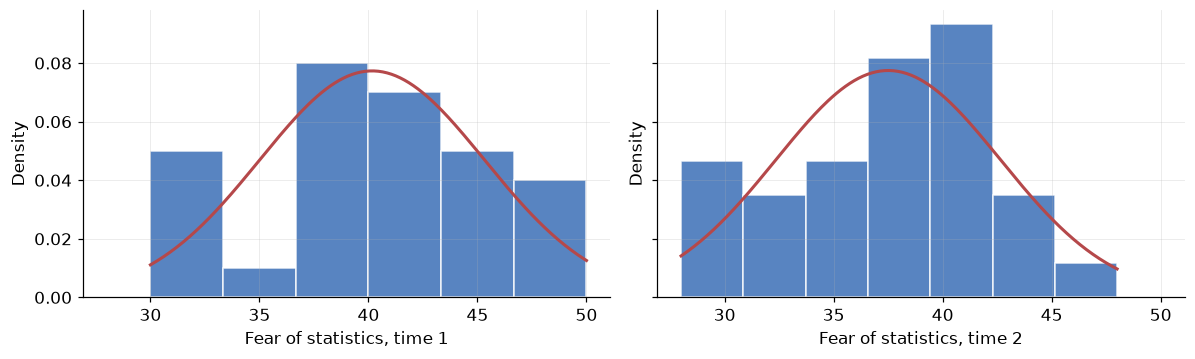

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharex=True, sharey=True)
m9.histogram_with_normal(experim.fost1, xlabel="Fear of statistics, time 1", ax=axes[0])
m9.histogram_with_normal(experim.fost2, xlabel="Fear of statistics, time 2", ax=axes[1])
fig.tight_layout();

Both distributions are roughly symmetric and similarly spread; the time 2
distribution sits a little lower. Note the shared axes — comparing two
histograms on different scales is comparing nothing.

### 5.2 Depression at time 1, by intervention group

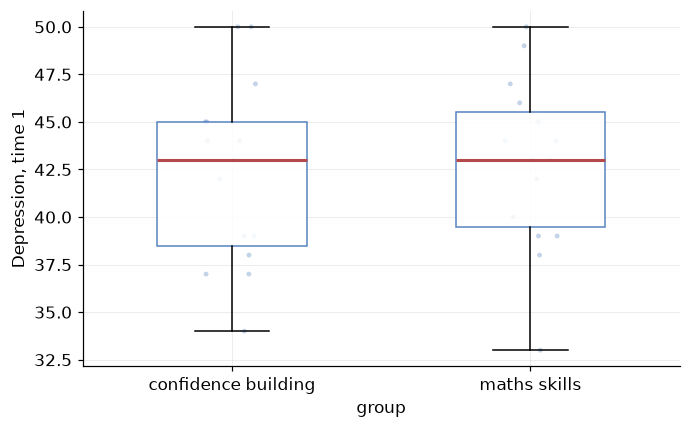

In [17]:
m9.grouped_box(experim, "depress1", "group", ylabel="Depression, time 1");

The two groups look very similar before the intervention, which is what you
would hope for at baseline.

### 5.3 Confidence in coping at time 1, by sex

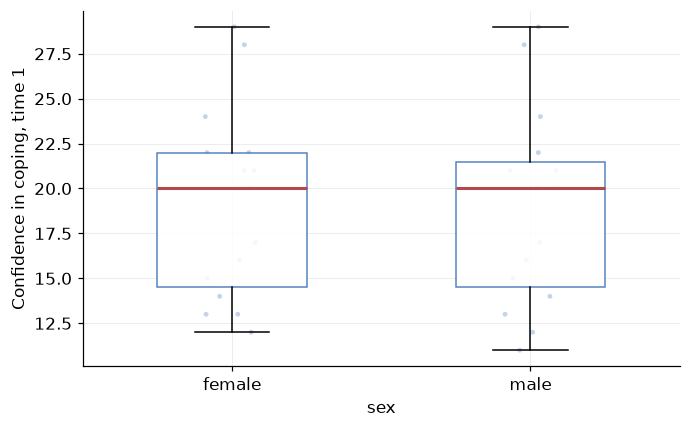

In [18]:
m9.grouped_box(experim, "confid1", "sex", ylabel="Confidence in coping, time 1");

Confidence in coping at time 1 looks much the same for men and women: similar
medians, similar spread.

### 5.4 Exam marks

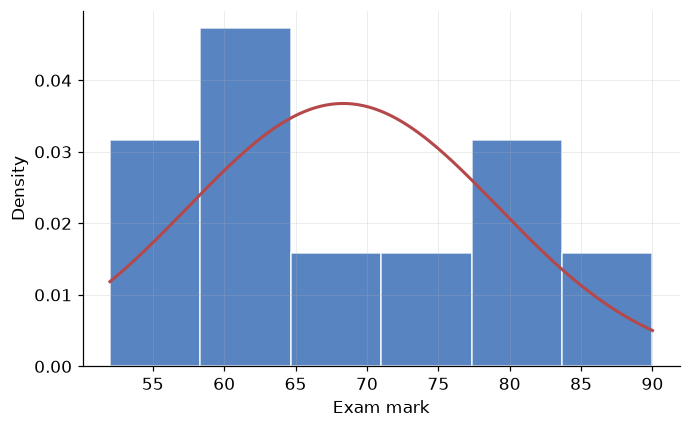

In [19]:
m9.histogram_with_normal(experim.exam, xlabel="Exam mark");

Exam results are spread broadly and fairly evenly across their range, with no
clear peak.

**The one whose design changes the plot: 5.1.** Time 1 and time 2 are the *same
students* measured twice, as Question 1 established. Two histograms side by side
show how the group moved as a whole and hide how each student moved. The plot
that respects the pairing is the within-student change:

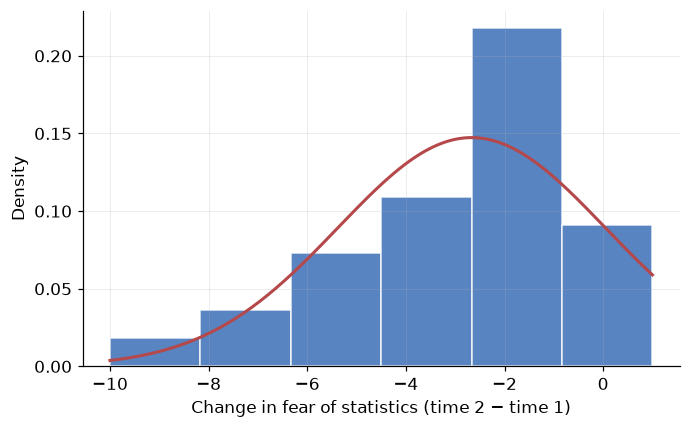

In [20]:
m9.histogram_with_normal(experim.fost2 - experim.fost1,
                         xlabel="Change in fear of statistics (time 2 − time 1)");

Most students' fear fell, and a few rose. The other three are right as they
stand: 5.2 and 5.3 compare separate groups of students, where boxplots side by
side are right, and 5.4 is a single distribution, where a histogram is right.

---

## Question 6 — Look for outliers

In [21]:
def fence_report(series, name):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = series[(series < lo) | (series > hi)]
    print(f"{name:9s} fences {lo:7.2f} to {hi:7.2f}   beyond: {len(flagged)}"
          f"   {sorted(flagged.tolist())}")

for col in ("age", "exam", "depress1"):
    fence_report(experim[col], col)

age       fences   12.38 to   35.38   beyond: 4   [37, 45, 45, 46]
exam      fences   30.00 to  108.00   beyond: 0   []
depress1  fences   30.00 to   54.00   beyond: 0   []


age skew = +1.64


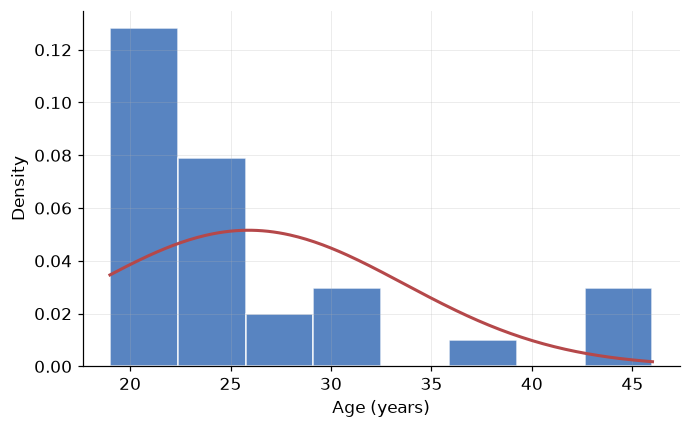

In [22]:
print(f"age skew = {stats.skew(experim.age):+.2f}")
m9.histogram_with_normal(experim.age, xlabel="Age (years)");

**`exam` and `depress1` flag nothing.** Both are broad and roughly symmetric, so
the fences sit outside the observed range.

**`age` flags several values** — and they are not errors, or even surprising.
They are the oldest students in a cohort that is mostly in its early twenties.
The variable is right-skewed, and **the 1.5 × IQR rule flags points in the tail
of a skewed distribution as a matter of arithmetic**, whether or not anything is
wrong with them.

That is the real lesson of the question. The fence is a *screening device*, not
a verdict. On a skewed variable it will flag ordinary observations, and deleting
them would make the sample less representative, not more.

**What to actually do.**

- A value you **do not believe** — outside the possible range of the scale, or
  impossible given the design — is a data-quality problem. Find out what
  happened, correct it if you can, and if you cannot, exclude it and say so in
  the write-up.
- A value you **do believe** stays in. It is a real member of the population you
  are describing. Report that the distribution is skewed, and use summaries that
  survive it — median and IQR.

**How to tell them apart here.** By checking against what the variable can
legitimately be. Ages from the late thirties to the mid-forties are perfectly
possible for a student.
Contrast the festival hygiene score of twenty from the notebook, on a scale that
runs to four: that one is impossible, so it is an error.

---

## Question 7 — Did the intervention work?

In [23]:
m9.describe_by(experim, "fost1", "group")

,n,missing,mean,sd,se,median,iqr,min,max,skew,kurtosis
group,,,,,,,,,,,
confidence building,15.0,0.0,40.467,5.817,1.502,40.0,7.5,30.0,50.0,-0.285,-0.641
maths skills,15.0,0.0,39.867,4.596,1.187,39.0,5.5,32.0,47.0,-0.156,-0.383


In [24]:
m9.describe_by(experim, "fost2", "group")

,n,missing,mean,sd,se,median,iqr,min,max,skew,kurtosis
group,,,,,,,,,,,
confidence building,15.0,0.0,37.333,5.876,1.517,37.0,5.5,28.0,48.0,0.115,-0.484
maths skills,15.0,0.0,37.667,4.515,1.166,39.0,4.0,28.0,45.0,-0.748,0.273


In [25]:
change = experim.assign(change=experim.fost2 - experim.fost1)
m9.describe_by(change, "change", "group")

,n,missing,mean,sd,se,median,iqr,min,max,skew,kurtosis
group,,,,,,,,,,,
confidence building,15.0,0.0,-3.133,2.924,0.755,-2.0,3.5,-10.0,1.0,-0.916,0.712
maths skills,15.0,0.0,-2.200,2.484,0.641,-1.0,3.0,-7.0,1.0,-0.350,-0.855


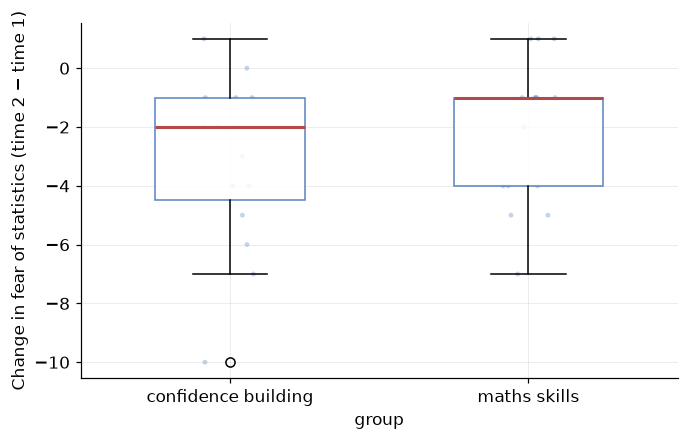

In [26]:
m9.grouped_box(change, "change", "group",
               ylabel="Change in fear of statistics (time 2 − time 1)");

Note what the third cell does. Because each student is measured twice, the
**within-student change** is available and is a far more informative quantity
than either group mean. A comparison of `fost1` against `fost2` across the whole
group throws that pairing away.

**Three sentences.**

> Fear of statistics fell on average between the start and the end of the
> programme, and the size of that fall was similar in the two intervention
> groups. Individual students varied a great deal — some improved substantially,
> others did not change or got worse — so the group averages hide a wide range
> of experiences. With fifteen students in each group, and no untreated
> comparison group, these figures describe what happened to these particular
> students and cannot separate the effect of either programme from the effect of
> simply having spent a term in the course.

The third sentence is the one that matters. Two treated groups with no
control is a design that cannot answer "did the intervention work", only "did
the two interventions differ from each other". Say so.

---

## Question 8 — Judgement

> "We plotted the mean fear-of-statistics score at time 2 for each group as a
> bar chart. The maths-skills bar is taller, so that intervention is worse. We
> set the y-axis to start at 37 so the difference would be visible."

**Three problems.**

1. **A bar of means hides everything that matters.** Two bars represent thirty
   students, and show neither the spread within each group nor how far the
   groups overlap. Here the groups overlap almost completely, and the bar chart
   cannot show that.

2. **The truncated axis manufactures the difference.** Starting the axis at 37
   is an explicit decision to make a small difference look large — here it makes
   one bar look twice the height of the other — and the sentence admits the
   intent. A bar chart's whole visual grammar is length from
   zero; truncate it and the lengths mean nothing.

3. **"Taller, so worse" is a causal conclusion from a descriptive difference.**
   Nothing has been tested, no effect size is given, the baseline scores are not
   accounted for, and there is no untreated group. Even with a test, a difference
   between two treated groups says which was better *relative to the other*, not
   that either was bad.

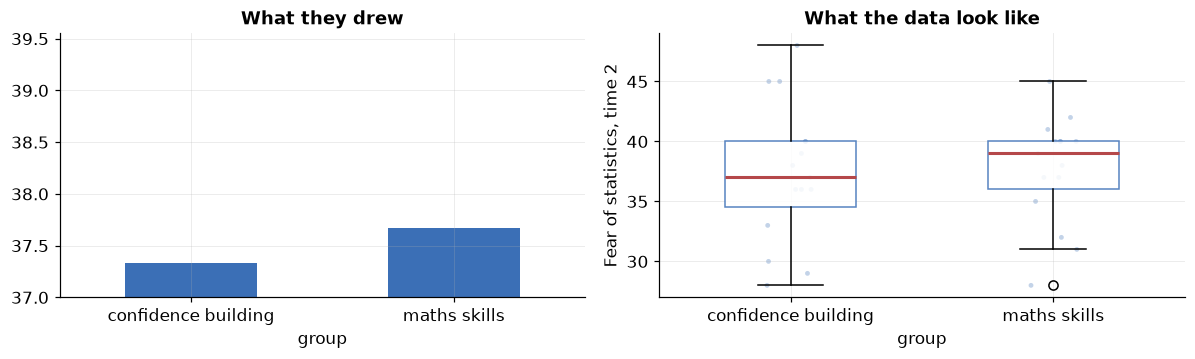

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

experim.groupby("group").fost2.mean().plot.bar(ax=axes[0], rot=0)
axes[0].set_ylim(37, None)
axes[0].set_title("What they drew")

m9.grouped_box(experim, "fost2", "group", ylabel="Fear of statistics, time 2", ax=axes[1])
axes[1].set_title("What the data look like")
fig.tight_layout();

**What to draw instead.** Boxplots of the change within each student, side by
side, with the individual points visible — which is what Question 7 produced. It
shows the centre, the spread, the sample size and the overlap, in the same space
the bar chart used to show two numbers.